In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report

In [2]:
df = pd.read_csv('D:/Broadway/Data Science - 2/student.csv')
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,higher education,higher education,at_home,teacher,...,very good,medium,high,very low,very low,good,6,5,6,6
1,GP,F,17,U,GT3,T,primary education (4th grade),primary education (4th grade),at_home,other,...,excellent,medium,medium,very low,very low,good,4,5,5,6
2,GP,F,15,U,LE3,T,primary education (4th grade),primary education (4th grade),at_home,other,...,very good,medium,low,low,medium,good,10,7,8,10
3,GP,F,15,U,GT3,T,higher education,5th to 9th grade,health,services,...,good,low,low,very low,very low,excellent,2,15,14,15
4,GP,F,16,U,GT3,T,secondary education,secondary education,other,other,...,very good,medium,low,very low,low,excellent,4,6,10,10


In [3]:
df.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')

In [4]:
df['health'].unique()

array(['good', 'excellent', 'very bad', 'bad', 'very good'], dtype=object)

In [5]:
m_edu_id = {
    'primary education (4th grade)': 0,
    '5th to 9th grade': 1,
    'secondary education': 2,
    'higher education': 3,
    'none': 4
}
df['Medu_ID'] = df['Medu'].map(m_edu_id)

In [6]:
f_edu_id = {
    'primary education (4th grade)': 0,
    '5th to 9th grade': 1,
    'secondary education': 2,
    'higher education': 3,
    'none': 4
}
df['Fedu_ID'] = df['Fedu'].map(f_edu_id)

In [7]:
travel_id = {
    '<15 min.': 0,
    '15 to 30 min.': 1, 
    '30 min. to 1 hour': 2, 
    '>1 hour': 3
}
df['traveltime_id'] = df['traveltime'].map(travel_id) 

In [8]:
study_id = {
    '<2 hours': 0, 
    '2 to 5 hours': 1, 
    '5 to 10 hours': 2, 
    '>10 hours': 3
}
df['studytime_id'] = df['studytime'].map(study_id)

In [9]:
internet_id = {
    'no': 0, 
    'yes': 1
}
df['internet_id'] = df['internet'].map(internet_id)

In [10]:
goout_id = {
    'very low': 0, 
    'low': 1, 
    'medium': 2, 
    'high': 3, 
    'very high': 4
}
df['goout_id'] = df['goout'].map(goout_id)

In [11]:
dalc_id = {
    'very low': 0, 
    'low': 1, 
    'medium': 2, 
    'high': 3, 
    'very high': 4
}
df['dalc_id'] = df['Dalc'].map(dalc_id)

In [12]:
walc_id = {
    'very low': 0, 
    'low': 1, 
    'medium': 2, 
    'high': 3, 
    'very high': 4
}
df['walc_id'] = df['Walc'].map(walc_id)

In [13]:
health_id = {
    'very bad': 0, 
    'bad': 1,
    'good': 2, 
    'very good': 3,
    'excellent': 4  
}
df['health_id'] = df['health'].map(health_id)

In [16]:
def grade(score):
    if score >= 16:
        return 'A'
    elif score >= 14 and score < 16:
        return 'B'
    elif score >= 10 and score < 14:
        return 'C'
    else:
        return 'Fail'

In [17]:
df['Grade'] = df['G3'].apply(grade)

# label encoding

In [19]:
le = LabelEncoder()

In [20]:
df['grade_id'] = le.fit_transform(df['Grade'])

In [22]:
df.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3', 'Medu_ID', 'Fedu_ID',
       'traveltime_id', 'studytime_id', 'internet_id', 'goout_id', 'dalc_id',
       'walc_id', 'health_id', 'Grade', 'grade_id'],
      dtype='object')

In [23]:
features = ['Medu_ID', 'Fedu_ID', 'traveltime_id', 'studytime_id', 'internet_id', 'goout_id', 'dalc_id',
            'walc_id', 'health_id', 'failures', 'absences', 'G1', 'G2']
target = 'grade_id'

In [24]:
X = df[features]
Y = df[target]

In [26]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

In [28]:
scaler = StandardScaler()
X_train_scale = scaler.fit_transform(X_train) # Learning + implement
X_test_scale = scaler.transform(X_test) # Implement

In [29]:
error_rate = []
k_range = range(1, 21)

In [30]:
for i in k_range:
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train_scale, Y_train)
    knn_pred = knn.predict(X_test_scale)
    error_rate.append(np.mean(knn_pred != Y_test))

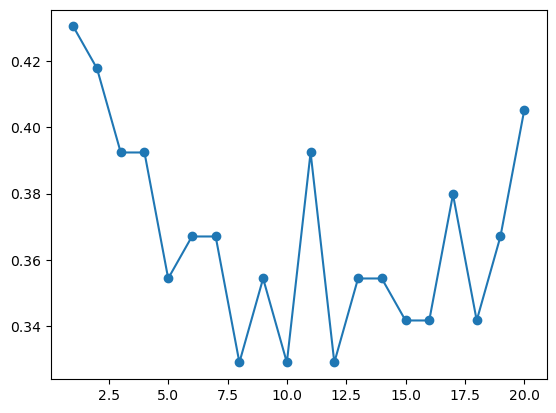

In [32]:
plt.plot(k_range, error_rate, marker='o')

In [42]:
model = KNeighborsClassifier(n_neighbors=8) # optimal number of K
model.fit(X_train_scale, Y_train)
Y_pred = model.predict(X_test_scale)

In [43]:
cr = classification_report(Y_test, Y_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.67      0.40      0.50        10
           1       0.67      0.50      0.57        16
           2       0.57      0.88      0.70        26
           3       0.86      0.67      0.75        27

    accuracy                           0.67        79
   macro avg       0.69      0.61      0.63        79
weighted avg       0.70      0.67      0.66        79

